# Bitcoin Market Sentiment vs Hyperliquid Trader Performance

## 1. Project Introduction

This notebook analyzes the relationship between **Bitcoin market sentiment** (Fear & Greed Index) and the **trading behavior / performance** of Hyperliquid traders. The goal is to uncover actionable insights about how trader profitability, risk-taking, and trading volume change across different sentiment regimes (Extreme Fear, Fear, Neutral, Greed, Extreme Greed).

**Scope**: 211,224 trade records from 32 unique accounts (May 2023 - May 2025), merged with daily BTC Fear & Greed classifications (Feb 2018 - May 2025).


## 2. Dataset Description

**Dataset 1 - Bitcoin Market Sentiment (`fear_greed_index.csv`)**
- `timestamp`: Unix timestamp
- `value`: Fear & Greed Index value (0-100)
- `classification`: Fear, Extreme Fear, Neutral, Greed, Extreme Greed
- `date`: Calendar date

**Dataset 2 - Hyperliquid Historical Trader Data (`historical_data.csv`)**
- `Account`: Trader wallet address
- `Coin`: Traded asset
- `Execution Price`, `Size Tokens`, `Size USD`: Trade size details
- `Side`: BUY/SELL
- `Timestamp IST`: Trade execution time
- `Start Position`: Position size before the trade
- `Direction`: Open/Close Long/Short, etc.
- `Closed PnL`: Realized profit/loss on the trade
- `Fee`, `Trade ID`, etc.

**Note on leverage**: The raw data does not contain an explicit `leverage` field. As a practical proxy, we compute **position-size intensity** as `Size USD` relative to the trader's `Start Position` value, and use **trade size (Size USD)** as the primary measure of risk-taking / aggressiveness throughout this analysis. This is clearly labeled wherever used.


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

CHART_DIR = "outputs/charts"
import os
os.makedirs(CHART_DIR, exist_ok=True)


## 3. Data Cleaning & Preprocessing

In [10]:
# Load datasets
sentiment = pd.read_csv("data/fear_greed_index.csv")
trades = pd.read_csv("data/historical_data.csv")

print("Sentiment shape:", sentiment.shape)
print("Trades shape:", trades.shape)


Sentiment shape: (2644, 4)
Trades shape: (211224, 16)


In [11]:
# --- Clean sentiment data ---
sentiment['date'] = pd.to_datetime(sentiment['date'])
sentiment = sentiment[['date', 'value', 'classification']].drop_duplicates()
sentiment = sentiment.sort_values('date').reset_index(drop=True)

print("Missing values in sentiment:\n", sentiment.isnull().sum())
print("Duplicate rows:", sentiment.duplicated().sum())
print("\nClassification distribution:")
print(sentiment['classification'].value_counts())


Missing values in sentiment:
 date              0
value             0
classification    0
dtype: int64
Duplicate rows: 0

Classification distribution:
classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64


In [12]:
# --- Clean trader data ---
print("Missing values in trades:\n", trades.isnull().sum())
print("Duplicate rows:", trades.duplicated().sum())

# Convert timestamp to datetime and extract date for merging
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M')
trades['date'] = trades['Timestamp IST'].dt.normalize()

# Standardize column names for ease of use
trades = trades.rename(columns={
    'Closed PnL': 'closedPnL',
    'Size USD': 'size_usd',
    'Size Tokens': 'size_tokens',
    'Execution Price': 'execution_price',
    'Start Position': 'start_position',
    'Side': 'side',
    'Direction': 'direction',
    'Account': 'account',
    'Coin': 'symbol'
})

print("\nDate range of trades:", trades['date'].min(), "to", trades['date'].max())
print("Unique accounts:", trades['account'].nunique())
print("Unique coins:", trades['symbol'].nunique())


Missing values in trades:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
Duplicate rows: 0

Date range of trades: 2023-05-01 00:00:00 to 2025-05-01 00:00:00
Unique accounts: 32
Unique coins: 246


## 4. Data Merging

Each trade is matched to the BTC sentiment classification of the same calendar date.

In [13]:
sentiment['date'] = sentiment['date'].dt.normalize()

merged = trades.merge(sentiment[['date', 'value', 'classification']], on='date', how='inner')

print("Trades before merge:", trades.shape[0])
print("Trades after merge:", merged.shape[0])
print("Trades dropped (no matching sentiment date):", trades.shape[0] - merged.shape[0])

# Order sentiment categories logically for plots
sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
merged['classification'] = pd.Categorical(merged['classification'], categories=sentiment_order, ordered=True)

merged.head()


Trades before merge: 211224
Trades after merge: 211218
Trades dropped (no matching sentiment date): 6


,account,symbol,execution_price,size_tokens,size_usd,side,Timestamp IST,start_position,direction,closedPnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,80,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,80,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,80,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,80,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,80,Extreme Greed


In [14]:
# Save cleaned & merged dataset summary
merged.to_csv("outputs/merged_dataset.csv", index=False)

print("=== Cleaned & Merged Dataset Summary ===")
print(f"Total trades: {len(merged):,}")
print(f"Date range: {merged['date'].min().date()} to {merged['date'].max().date()}")
print(f"Unique traders: {merged['account'].nunique()}")
print(f"Unique coins: {merged['symbol'].nunique()}")
print("\nTrade count by sentiment:")
print(merged['classification'].value_counts().reindex(sentiment_order))


=== Cleaned & Merged Dataset Summary ===
Total trades: 211,218
Date range: 2023-05-01 to 2025-05-01
Unique traders: 32
Unique coins: 246

Trade count by sentiment:
classification
Extreme Fear     21400
Fear             61837
Neutral          37686
Greed            50303
Extreme Greed    39992
Name: count, dtype: int64


## 5. Exploratory Data Analysis (EDA)

### 5.1 Distribution of Market Sentiment Categories

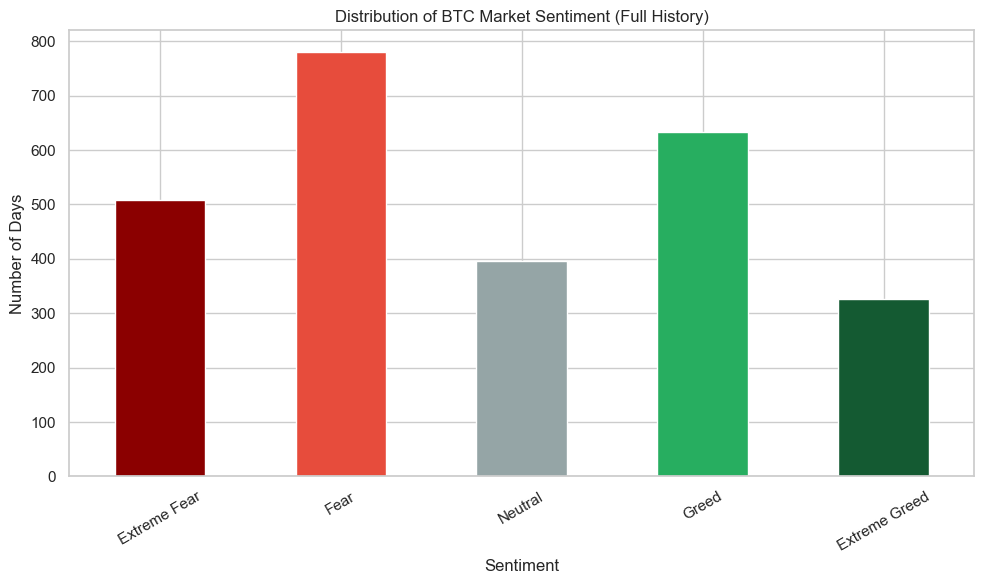

In [15]:
fig, ax = plt.subplots()
order_counts = sentiment['classification'].value_counts().reindex(sentiment_order)
colors = ['#8B0000', '#E74C3C', '#95A5A6', '#27AE60', '#145A32']
order_counts.plot(kind='bar', ax=ax, color=colors)
ax.set_title("Distribution of BTC Market Sentiment (Full History)")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Number of Days")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/sentiment_distribution.png", dpi=120)
plt.show()


**Explanation**: Across the full history (2018-2025), "Fear" is the most common sentiment state, followed by "Greed". Extreme states (Extreme Fear / Extreme Greed) are less frequent, which is expected since markets spend most time in moderate emotional states.

### 5.2 Distribution of Trader Profits and Losses

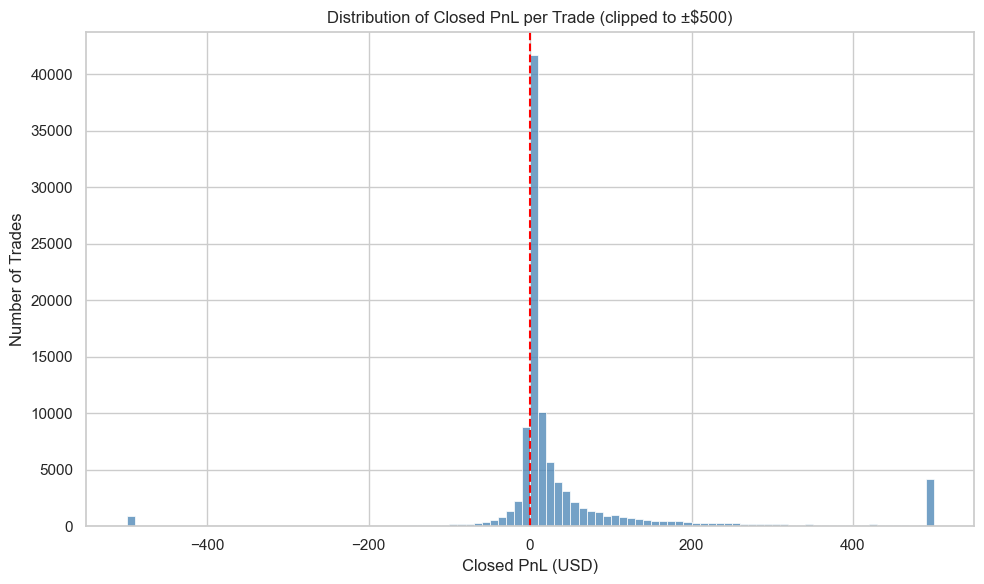

Closed PnL summary statistics:
count    211218.000000
mean         48.549304
std         917.989791
min     -117990.104100
25%           0.000000
50%           0.000000
75%           5.790132
max      135329.090100
Name: closedPnL, dtype: float64

% of trades with PnL = 0 (non-closing trades): 50.6%


In [16]:
fig, ax = plt.subplots()
pnl_clipped = merged['closedPnL'].clip(-500, 500)  # clip for visibility
sns.histplot(pnl_clipped[pnl_clipped != 0], bins=100, ax=ax, color='steelblue')
ax.set_title("Distribution of Closed PnL per Trade (clipped to ±$500)")
ax.set_xlabel("Closed PnL (USD)")
ax.set_ylabel("Number of Trades")
ax.axvline(0, color='red', linestyle='--')
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/pnl_distribution.png", dpi=120)
plt.show()

print("Closed PnL summary statistics:")
print(merged['closedPnL'].describe())
print(f"\n% of trades with PnL = 0 (non-closing trades): {(merged['closedPnL']==0).mean()*100:.1f}%")


**Explanation**: Most trades have a Closed PnL of exactly 0 - these are trade-opening/position-building executions where no profit is realized yet. The remaining trades (position closes) show a typical fat-tailed distribution: many small gains/losses with occasional large wins or losses.

### 5.3 Trading Volume Across Sentiment Categories

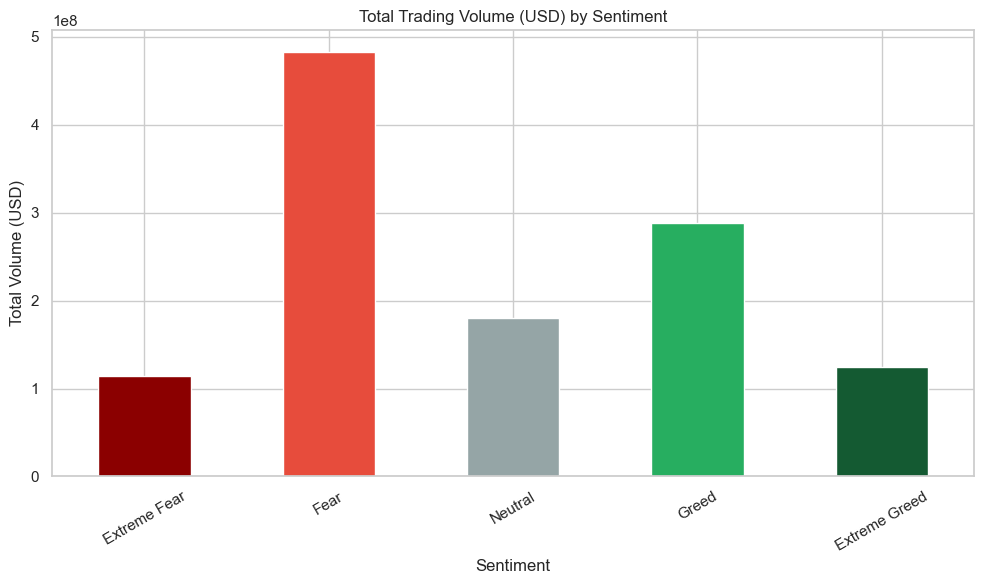

classification
Extreme Fear     1.144843e+08
Fear             4.833248e+08
Neutral          1.802421e+08
Greed            2.885825e+08
Extreme Greed    1.244652e+08
Name: size_usd, dtype: float64


In [17]:
volume_by_sentiment = merged.groupby('classification', observed=True)['size_usd'].sum().reindex(sentiment_order)

fig, ax = plt.subplots()
volume_by_sentiment.plot(kind='bar', ax=ax, color=colors)
ax.set_title("Total Trading Volume (USD) by Sentiment")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Total Volume (USD)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/volume_by_sentiment.png", dpi=120)
plt.show()

print(volume_by_sentiment)


### 5.4 Average Position Size (Risk Proxy) Under Different Sentiments

Since the dataset has no explicit `leverage` column, we use **average trade size (Size USD)** per trade as a proxy for risk-taking intensity.

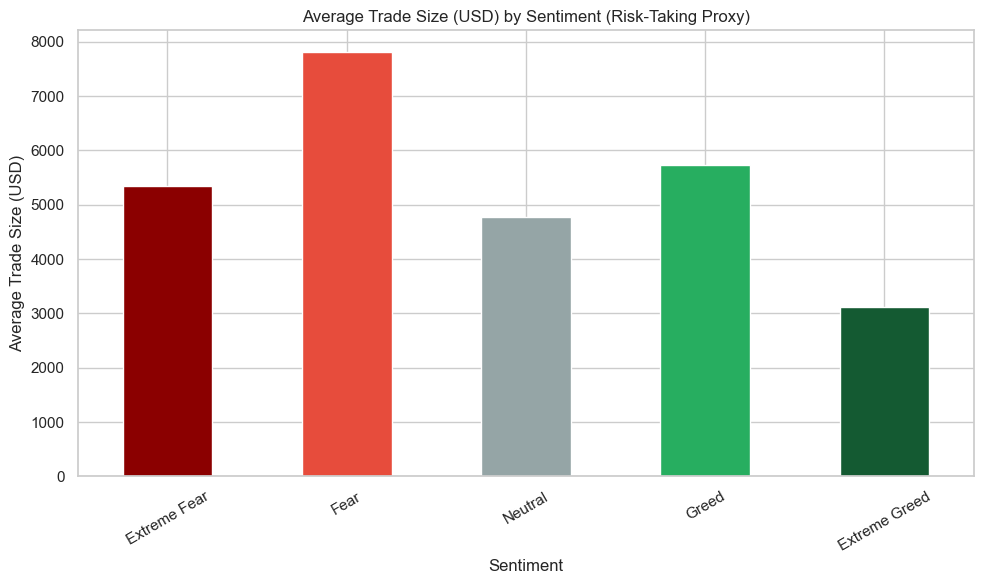

classification
Extreme Fear     5349.731843
Fear             7816.109931
Neutral          4782.732661
Greed            5736.884375
Extreme Greed    3112.251565
Name: size_usd, dtype: float64


In [18]:
avg_size_by_sentiment = merged.groupby('classification', observed=True)['size_usd'].mean().reindex(sentiment_order)

fig, ax = plt.subplots()
avg_size_by_sentiment.plot(kind='bar', ax=ax, color=colors)
ax.set_title("Average Trade Size (USD) by Sentiment (Risk-Taking Proxy)")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Average Trade Size (USD)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/avg_size_by_sentiment.png", dpi=120)
plt.show()

print(avg_size_by_sentiment)


### 5.5 Buy vs Sell Activity Across Sentiments

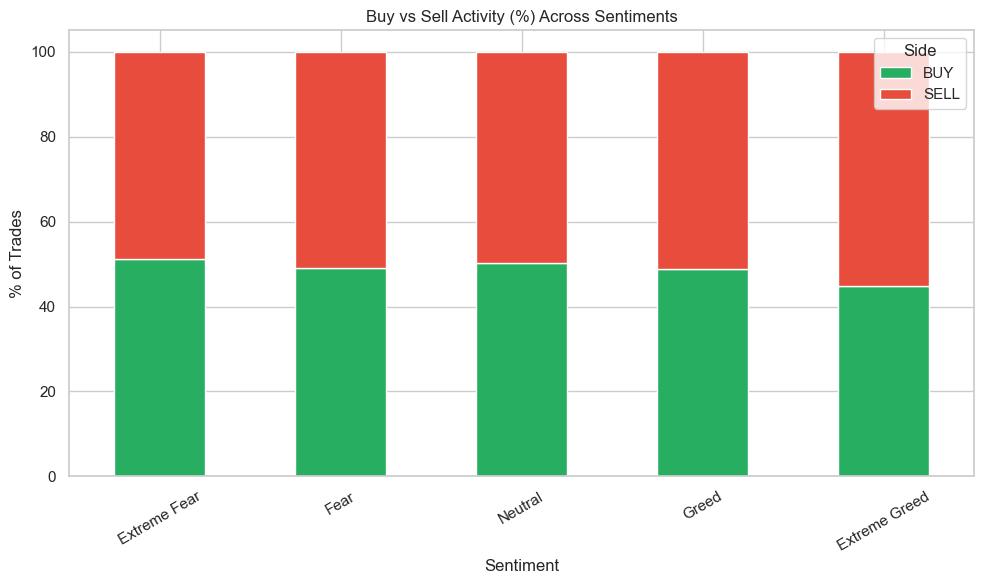

side             BUY  SELL
classification            
Extreme Fear    51.1  48.9
Fear            49.0  51.0
Neutral         50.3  49.7
Greed           48.9  51.1
Extreme Greed   44.9  55.1


In [19]:
side_sentiment = merged.groupby(['classification', 'side'], observed=True).size().unstack().reindex(sentiment_order)
side_sentiment_pct = side_sentiment.div(side_sentiment.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots()
side_sentiment_pct.plot(kind='bar', stacked=True, ax=ax, color=['#27AE60', '#E74C3C'])
ax.set_title("Buy vs Sell Activity (%) Across Sentiments")
ax.set_xlabel("Sentiment")
ax.set_ylabel("% of Trades")
ax.legend(title='Side')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/buy_sell_by_sentiment.png", dpi=120)
plt.show()

print(side_sentiment_pct.round(1))


### 5.6 Number of Trades Executed Under Each Sentiment Condition

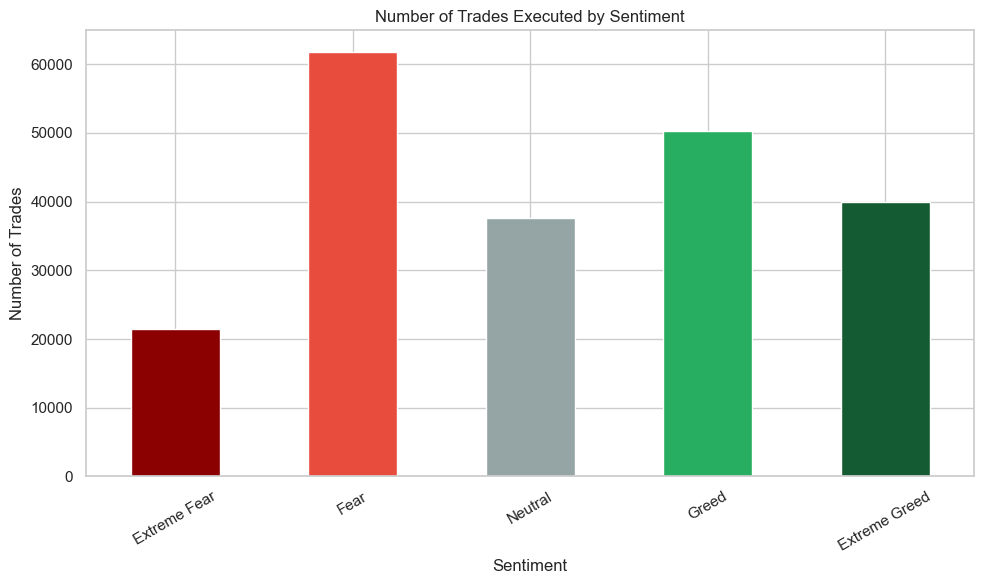

classification
Extreme Fear     21400
Fear             61837
Neutral          37686
Greed            50303
Extreme Greed    39992
Name: count, dtype: int64


In [20]:
trade_counts = merged['classification'].value_counts().reindex(sentiment_order)

fig, ax = plt.subplots()
trade_counts.plot(kind='bar', ax=ax, color=colors)
ax.set_title("Number of Trades Executed by Sentiment")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Number of Trades")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/trade_counts_by_sentiment.png", dpi=120)
plt.show()

print(trade_counts)


## 6. Sentiment vs Trader Performance Analysis

### 6.1 Average & Median Closed PnL by Sentiment

                      mean    median         total  count
classification                                           
Extreme Fear     71.027316  6.388050  7.391102e+05  10406
Fear            112.625988  6.350483  3.357155e+06  29808
Neutral          71.199993  4.583458  1.292921e+06  18159
Greed            85.403927  4.927600  2.150129e+06  25176
Extreme Greed   130.205309  8.530740  2.715171e+06  20853


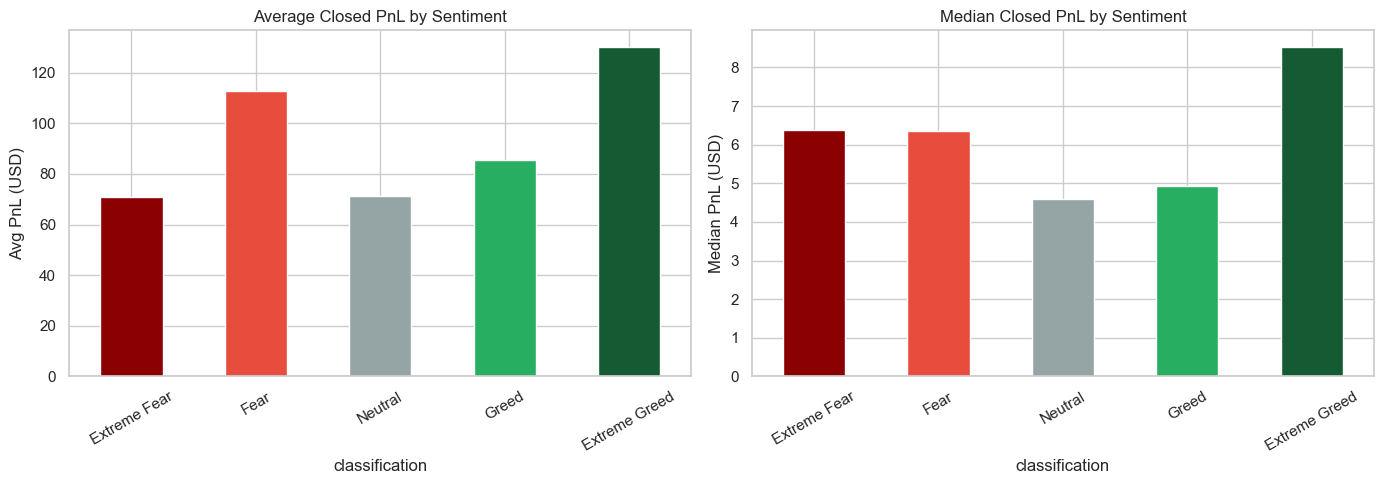

In [21]:
# Focus on trades where a position was actually closed (PnL != 0)
closed_trades = merged[merged['closedPnL'] != 0].copy()

pnl_stats = closed_trades.groupby('classification', observed=True)['closedPnL'].agg(
    mean='mean', median='median', total='sum', count='count'
).reindex(sentiment_order)

print(pnl_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pnl_stats['mean'].plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title("Average Closed PnL by Sentiment")
axes[0].set_ylabel("Avg PnL (USD)")
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].tick_params(axis='x', rotation=30)

pnl_stats['median'].plot(kind='bar', ax=axes[1], color=colors)
axes[1].set_title("Median Closed PnL by Sentiment")
axes[1].set_ylabel("Median PnL (USD)")
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(f"{CHART_DIR}/avg_median_pnl_by_sentiment.png", dpi=120)
plt.show()


### 6.2 Distribution of PnL by Sentiment (Box Plot)

C:\Users\Saiashish\AppData\Local\Temp\ipykernel_16184\776934895.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='classification', y='closedPnL', order=sentiment_order, palette=colors, ax=ax)


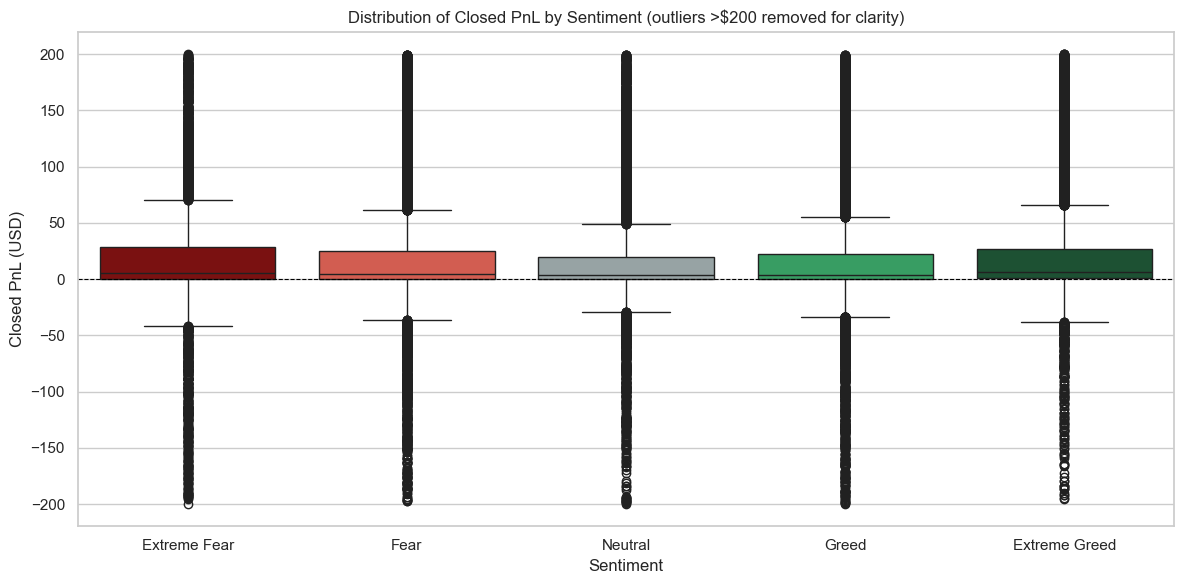

In [22]:
fig, ax = plt.subplots(figsize=(12, 6))
plot_data = closed_trades[closed_trades['closedPnL'].abs() < 200]  # remove extreme outliers for visibility
sns.boxplot(data=plot_data, x='classification', y='closedPnL', order=sentiment_order, palette=colors, ax=ax)
ax.set_title("Distribution of Closed PnL by Sentiment (outliers >$200 removed for clarity)")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Closed PnL (USD)")
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/pnl_boxplot_by_sentiment.png", dpi=120)
plt.show()


### 6.3 Win Rate Under Fear, Neutral, and Greed Conditions

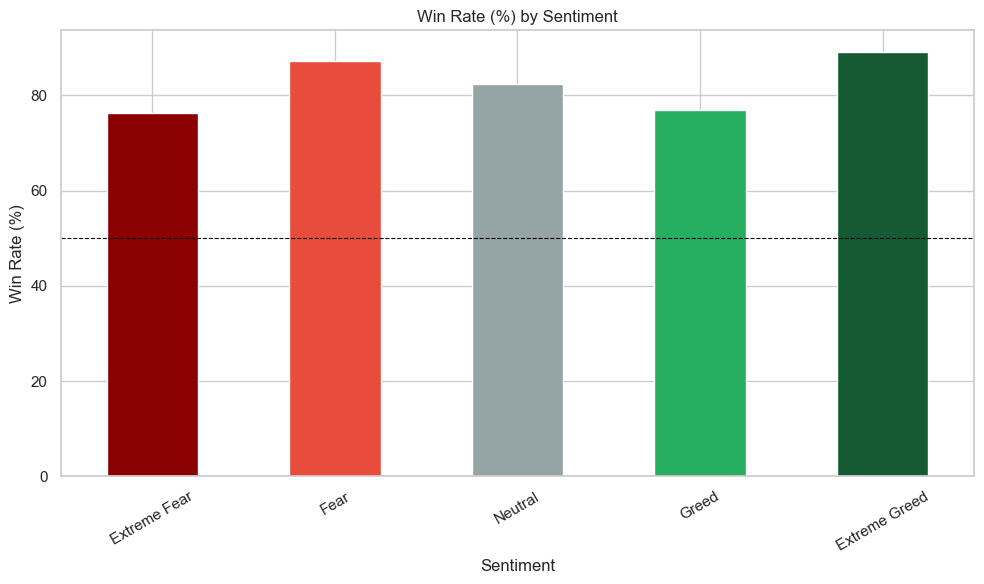

classification
Extreme Fear     76.22
Fear             87.29
Neutral          82.39
Greed            76.89
Extreme Greed    89.17
Name: closedPnL, dtype: float64


In [23]:
win_rate = closed_trades.groupby('classification', observed=True)['closedPnL'].apply(
    lambda x: (x > 0).mean() * 100
).reindex(sentiment_order)

fig, ax = plt.subplots()
win_rate.plot(kind='bar', ax=ax, color=colors)
ax.set_title("Win Rate (%) by Sentiment")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Win Rate (%)")
ax.axhline(50, color='black', linestyle='--', linewidth=0.8)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/win_rate_by_sentiment.png", dpi=120)
plt.show()

print(win_rate.round(2))


### 6.4 Fear vs Greed - Which Performs Better?

In [24]:
fear_group = closed_trades[closed_trades['classification'].isin(['Fear', 'Extreme Fear'])]
greed_group = closed_trades[closed_trades['classification'].isin(['Greed', 'Extreme Greed'])]
neutral_group = closed_trades[closed_trades['classification'] == 'Neutral']

comparison = pd.DataFrame({
    'Fear (incl. Extreme)': [fear_group['closedPnL'].mean(), fear_group['closedPnL'].median(),
                              (fear_group['closedPnL']>0).mean()*100, fear_group['closedPnL'].sum()],
    'Neutral': [neutral_group['closedPnL'].mean(), neutral_group['closedPnL'].median(),
                (neutral_group['closedPnL']>0).mean()*100, neutral_group['closedPnL'].sum()],
    'Greed (incl. Extreme)': [greed_group['closedPnL'].mean(), greed_group['closedPnL'].median(),
                               (greed_group['closedPnL']>0).mean()*100, greed_group['closedPnL'].sum()]
}, index=['Mean PnL', 'Median PnL', 'Win Rate (%)', 'Total PnL'])

print(comparison.round(2))


              Fear (incl. Extreme)     Neutral  Greed (incl. Extreme)
Mean PnL                    101.86       71.20                 105.70
Median PnL                    6.36        4.58                   6.49
Win Rate (%)                 84.42       82.39                  82.45
Total PnL               4096265.69  1292920.68             4865300.58


### 6.5 Position Size vs Profitability (Risk Proxy)

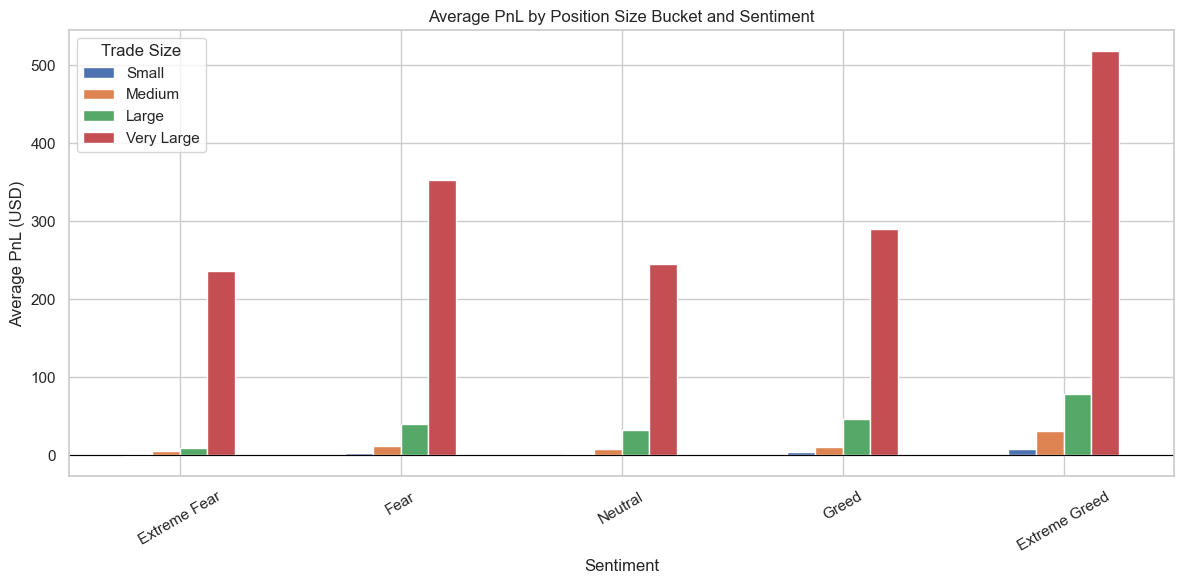

size_bucket     Small  Medium  Large  Very Large
classification                                  
Extreme Fear    -1.29    4.97   8.81      236.25
Fear             2.67   11.55  39.92      352.70
Neutral          1.21    7.85  32.59      245.59
Greed            3.82   10.23  46.20      289.49
Extreme Greed    8.04   31.56  78.52      518.44


In [25]:
# Bucket trade sizes into quartiles
closed_trades['size_bucket'] = pd.qcut(closed_trades['size_usd'], 4, labels=['Small', 'Medium', 'Large', 'Very Large'])

size_pnl = closed_trades.groupby(['classification', 'size_bucket'], observed=True)['closedPnL'].mean().unstack()

fig, ax = plt.subplots(figsize=(12, 6))
size_pnl.reindex(sentiment_order).plot(kind='bar', ax=ax)
ax.set_title("Average PnL by Position Size Bucket and Sentiment")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Average PnL (USD)")
ax.axhline(0, color='black', linewidth=0.8)
ax.legend(title='Trade Size')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/size_vs_pnl_by_sentiment.png", dpi=120)
plt.show()

print(size_pnl.round(2))


### 6.6 Correlation Heatmap (Numeric Features)

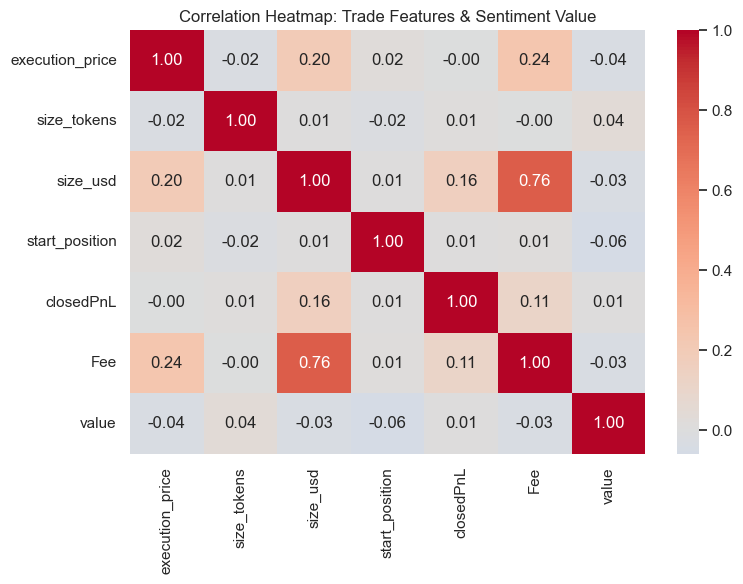

In [26]:
numeric_cols = ['execution_price', 'size_tokens', 'size_usd', 'start_position', 'closedPnL', 'Fee', 'value']
corr = closed_trades[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title("Correlation Heatmap: Trade Features & Sentiment Value")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/correlation_heatmap.png", dpi=120)
plt.show()


## 7. Behavioral Pattern Analysis

### 7.1 Are Traders More Aggressive (Larger Trades) During Greed?

In [27]:
agg_check = merged.groupby('classification', observed=True)['size_usd'].agg(['mean', 'median', 'count']).reindex(sentiment_order)
print(agg_check.round(2))

# % change vs Neutral baseline
baseline = agg_check.loc['Neutral', 'mean']
agg_check['% vs Neutral (mean size)'] = ((agg_check['mean'] - baseline) / baseline * 100).round(1)
print("\n", agg_check[['% vs Neutral (mean size)']])


                   mean  median  count
classification                        
Extreme Fear    5349.73  766.15  21400
Fear            7816.11  735.96  61837
Neutral         4782.73  547.66  37686
Greed           5736.88  555.00  50303
Extreme Greed   3112.25  500.05  39992

                 % vs Neutral (mean size)
classification                          
Extreme Fear                        11.9
Fear                                63.4
Neutral                              0.0
Greed                               19.9
Extreme Greed                      -34.9


### 7.2 Trade Frequency Intensity (Trades per Day) by Sentiment

This shows whether trading activity (frequency) ramps up during Extreme Greed/Fear.

classification
Extreme Fear      42.13
Fear              79.18
Neutral           95.17
Greed             79.47
Extreme Greed    122.67
Name: Trades per Day, dtype: float64


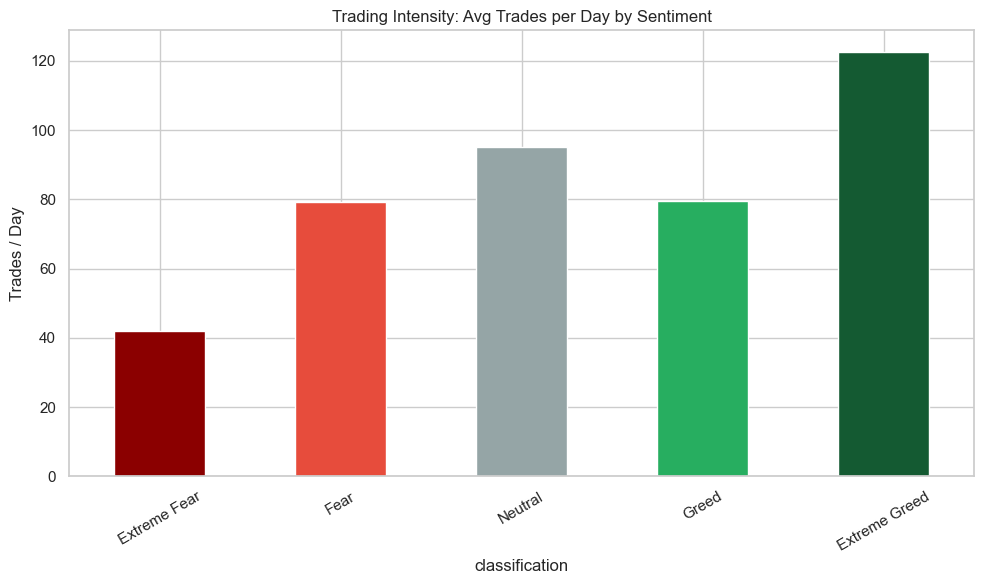

In [28]:
days_per_sentiment = sentiment['classification'].value_counts().reindex(sentiment_order)
trades_per_sentiment = merged['classification'].value_counts().reindex(sentiment_order)

intensity = (trades_per_sentiment / days_per_sentiment).rename("Trades per Day")
print(intensity.round(2))

fig, ax = plt.subplots()
intensity.plot(kind='bar', ax=ax, color=colors)
ax.set_title("Trading Intensity: Avg Trades per Day by Sentiment")
ax.set_ylabel("Trades / Day")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/trading_intensity.png", dpi=120)
plt.show()


### 7.3 Do Losses Increase During Extreme Fear?

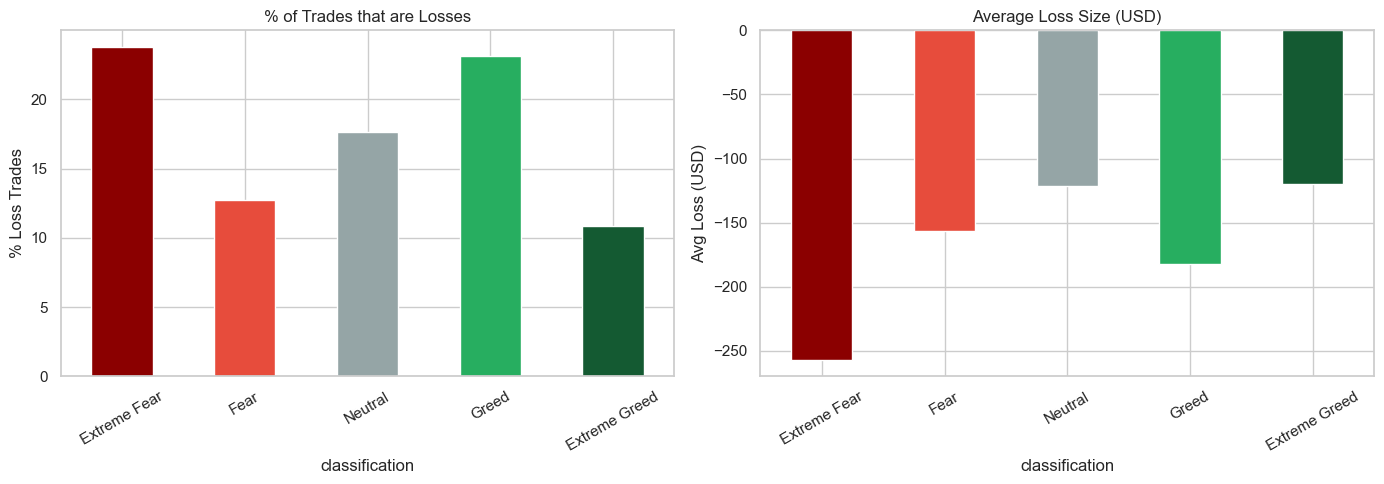

Loss share %:
 classification
Extreme Fear     23.78
Fear             12.71
Neutral          17.61
Greed            23.11
Extreme Greed    10.83
Name: closedPnL, dtype: float64

Avg loss size:
 classification
Extreme Fear    -257.10
Fear            -156.66
Neutral         -121.73
Greed           -181.97
Extreme Greed   -119.92
Name: closedPnL, dtype: float64


In [29]:
loss_share = closed_trades.groupby('classification', observed=True)['closedPnL'].apply(
    lambda x: (x < 0).mean() * 100
).reindex(sentiment_order)

avg_loss_size = closed_trades[closed_trades['closedPnL'] < 0].groupby('classification', observed=True)['closedPnL'].mean().reindex(sentiment_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
loss_share.plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title("% of Trades that are Losses")
axes[0].set_ylabel("% Loss Trades")
axes[0].tick_params(axis='x', rotation=30)

avg_loss_size.plot(kind='bar', ax=axes[1], color=colors)
axes[1].set_title("Average Loss Size (USD)")
axes[1].set_ylabel("Avg Loss (USD)")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(f"{CHART_DIR}/loss_patterns_by_sentiment.png", dpi=120)
plt.show()

print("Loss share %:\n", loss_share.round(2))
print("\nAvg loss size:\n", avg_loss_size.round(2))


### 7.4 Top vs Low Performing Traders Across Sentiments

Top 5 traders by total PnL:
account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
Name: closedPnL, dtype: float64

Bottom 5 traders by total PnL:
account
0x7f4f299f74eec87806a830e3caa9afa5f2b9db8f     14900.443047
0x39cef799f8b69da1995852eea189df24eb5cae3c     14456.919336
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891    -31203.599986
0x271b280974205ca63b716753467d5a371de622ab    -70436.191318
0x8170715b3b381dffb7062c0298972d4727a0a63b   -167621.124781
Name: closedPnL, dtype: float64


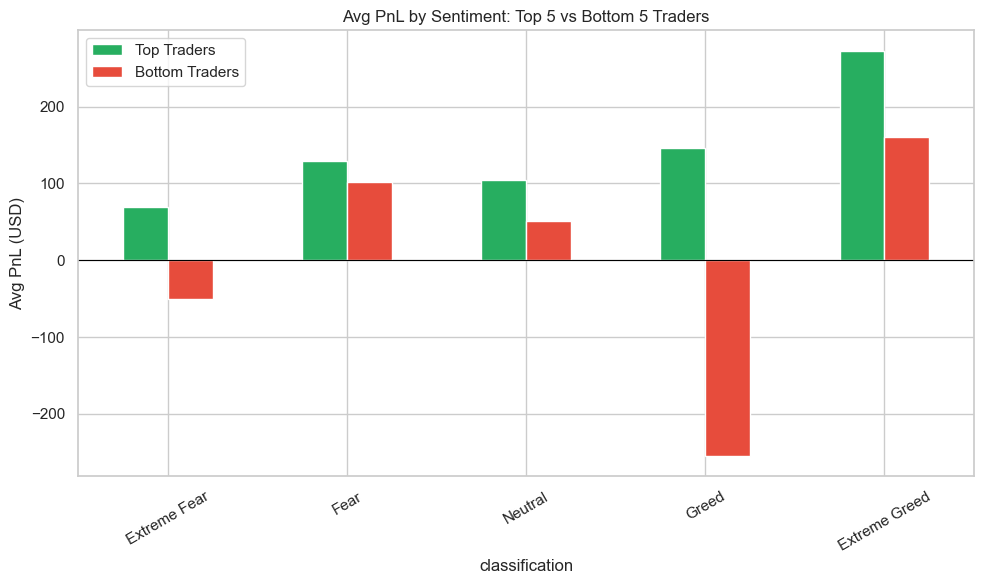

                Top Traders  Bottom Traders
classification                             
Extreme Fear          68.84          -50.20
Fear                 129.82          102.12
Neutral              104.22           50.54
Greed                145.78         -255.02
Extreme Greed        272.81          161.08


In [30]:
trader_pnl = closed_trades.groupby('account')['closedPnL'].sum().sort_values(ascending=False)
top_traders = trader_pnl.head(5).index
bottom_traders = trader_pnl.tail(5).index

print("Top 5 traders by total PnL:")
print(trader_pnl.head(5))
print("\nBottom 5 traders by total PnL:")
print(trader_pnl.tail(5))

top_behavior = closed_trades[closed_trades['account'].isin(top_traders)].groupby('classification', observed=True)['closedPnL'].mean().reindex(sentiment_order)
bottom_behavior = closed_trades[closed_trades['account'].isin(bottom_traders)].groupby('classification', observed=True)['closedPnL'].mean().reindex(sentiment_order)

comp_df = pd.DataFrame({'Top Traders': top_behavior, 'Bottom Traders': bottom_behavior})

fig, ax = plt.subplots()
comp_df.plot(kind='bar', ax=ax, color=['#27AE60', '#E74C3C'])
ax.set_title("Avg PnL by Sentiment: Top 5 vs Bottom 5 Traders")
ax.set_ylabel("Avg PnL (USD)")
ax.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/top_vs_bottom_traders.png", dpi=120)
plt.show()

print(comp_df.round(2))


## 8. Key Findings (Top 10 Insights)

Run the cell below to compute the final numeric summary that backs these findings, then read the written summary.

In [31]:
print("=== SUMMARY STATISTICS FOR FINDINGS ===\n")

print("1. Overall trade count by sentiment:")
print(trade_counts, "\n")

print("2. Mean/Median PnL by sentiment:")
print(pnl_stats[['mean','median']].round(2), "\n")

print("3. Win rate by sentiment:")
print(win_rate.round(2), "\n")

print("4. Best sentiment by mean PnL:", pnl_stats['mean'].idxmax(),
      f"(${pnl_stats['mean'].max():.2f})")
print("5. Worst sentiment by mean PnL:", pnl_stats['mean'].idxmin(),
      f"(${pnl_stats['mean'].min():.2f})")

print("\n6. Avg trade size by sentiment:")
print(avg_size_by_sentiment.round(2), "\n")

print("7. Trading intensity (trades/day):")
print(intensity.round(2), "\n")

print("8. Total PnL contribution by sentiment:")
print(pnl_stats['total'].round(2), "\n")

print("9. Fear vs Greed comparison:")
print(comparison.round(2), "\n")


=== SUMMARY STATISTICS FOR FINDINGS ===

1. Overall trade count by sentiment:
classification
Extreme Fear     21400
Fear             61837
Neutral          37686
Greed            50303
Extreme Greed    39992
Name: count, dtype: int64 

2. Mean/Median PnL by sentiment:
                  mean  median
classification                
Extreme Fear     71.03    6.39
Fear            112.63    6.35
Neutral          71.20    4.58
Greed            85.40    4.93
Extreme Greed   130.21    8.53 

3. Win rate by sentiment:
classification
Extreme Fear     76.22
Fear             87.29
Neutral          82.39
Greed            76.89
Extreme Greed    89.17
Name: closedPnL, dtype: float64 

4. Best sentiment by mean PnL: Extreme Greed ($130.21)
5. Worst sentiment by mean PnL: Extreme Fear ($71.03)

6. Avg trade size by sentiment:
classification
Extreme Fear     5349.73
Fear             7816.11
Neutral          4782.73
Greed            5736.88
Extreme Greed    3112.25
Name: size_usd, dtype: float64 

7. Trad